Instalación de dependencias para el pipeline de BreastMNIST



In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

Importación de módulos y carga de metadatos de BreastMNIST

In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

# Cambiamos el dataset a breastmnist
data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

Carga y partición del dataset BreastMNIST con transformación básica

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)

100%|██████████| 560k/560k [00:01<00:00, 553kB/s]


(546, 78, 156)

Visualización de muestras de entrenamiento

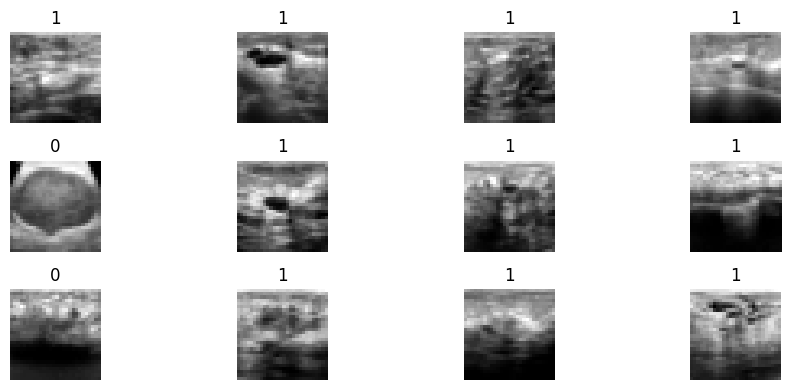

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

Selección del dispositivo de cómputo (GPU/CPU)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Configuración de DataLoaders para procesamiento por lotes

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

Definición de la arquitectura convolucional base (SimpleCNN)

In [7]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Capa 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Capa 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Capa 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Capa 4 (¡La nueva capa que sugirió tu profesora!)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            # Ahora la entrada es 128 porque nuestra última capa tiene 128 filtros
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.3, inplace=False)
    (15): Conv2d(64, 128, kernel_size=(3, 3)

Funciones auxiliares para entrenamiento y evaluación

In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    # Cálculos de métricas (Sin el F1)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return acc, auc, y_true, y_pred, y_prob # <--- Volvemos a los 5 valores originales

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

Bucle de entrenamiento y validación de SimpleCNN (Baseline)

In [9]:
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np

# 1. ESTO ES LO CRÍTICO: Volvemos a crear el modelo para "borrarle la memoria"
model_scratch = SimpleCNN(num_classes=num_classes).to(device)

# 2. Volvemos a crear el optimizador y el scheduler atados a este nuevo modelo virgen
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 55

history_scratch = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_auc": []
}

for epoch in range(1, epochs + 1):
    # Entrenamiento
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)

    # Avanzamos el scheduler
    scheduler.step()

    # Cálculo de val_loss
    model_scratch.eval()
    val_losses = []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device).long().squeeze(1)
            loss = criterion(model_scratch(x), y)
            val_losses.append(loss.item())
    val_loss = float(np.mean(val_losses))

    # Evaluación
    eval_results = evaluate(model_scratch, val_loader)
    val_acc = eval_results[0]
    val_auc = eval_results[1]

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6173 | val_loss=0.6749 | val_acc=0.7308 | val_auc=0.5982
Epoch 02 | train_loss=0.5836 | val_loss=0.6528 | val_acc=0.7308 | val_auc=0.6917
Epoch 03 | train_loss=0.5408 | val_loss=0.6090 | val_acc=0.7308 | val_auc=0.7243
Epoch 04 | train_loss=0.5569 | val_loss=0.5880 | val_acc=0.7308 | val_auc=0.7327
Epoch 05 | train_loss=0.5751 | val_loss=0.5906 | val_acc=0.7308 | val_auc=0.7419
Epoch 06 | train_loss=0.5442 | val_loss=0.5896 | val_acc=0.7308 | val_auc=0.7368
Epoch 07 | train_loss=0.5022 | val_loss=0.5821 | val_acc=0.7821 | val_auc=0.7460
Epoch 08 | train_loss=0.5314 | val_loss=0.5623 | val_acc=0.7949 | val_auc=0.7402
Epoch 09 | train_loss=0.5027 | val_loss=0.5443 | val_acc=0.7821 | val_auc=0.7385
Epoch 10 | train_loss=0.5016 | val_loss=0.5309 | val_acc=0.7949 | val_auc=0.7460
Epoch 11 | train_loss=0.5252 | val_loss=0.5212 | val_acc=0.7821 | val_auc=0.7594
Epoch 12 | train_loss=0.5018 | val_loss=0.5099 | val_acc=0.7692 | val_auc=0.7744
Epoch 13 | train_loss=0.4816

Visualización de curvas de aprendizaje y métricas (SimpleCNN)

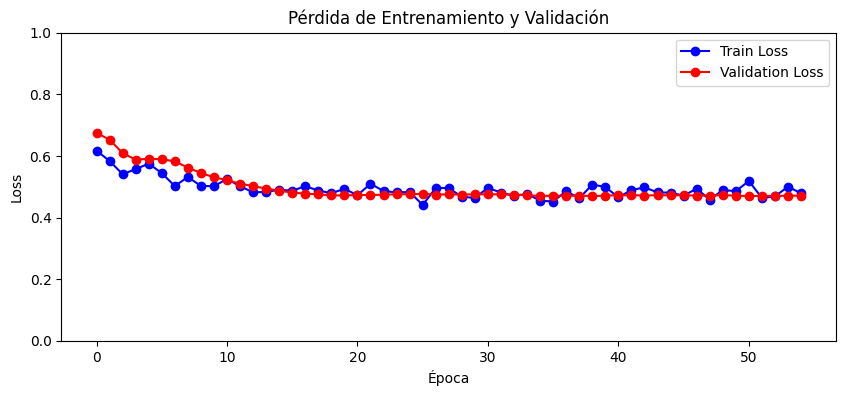

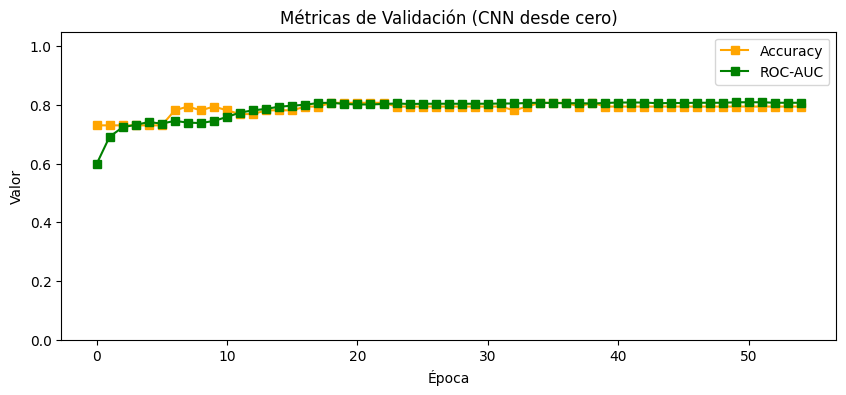

In [10]:
import matplotlib.pyplot as plt

# Gráfico 1: Train Loss vs Val Loss
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train Loss", color="blue", marker="o")
plt.plot(history_scratch["val_loss"], label="Validation Loss", color="red", marker="o")
plt.title("Pérdida de Entrenamiento y Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.ylim(0, 1.0) # <--- Forzamos el marco del gráfico para que vaya de 0 a 1
plt.legend()
plt.show()

# Gráfico 2: Accuracy vs ROC-AUC
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy", color="orange", marker="s")
plt.plot(history_scratch["val_auc"], label="ROC-AUC", color="green", marker="s")
plt.title("Métricas de Validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1.05) # <--- Forzamos el marco del gráfico para que vaya de 0 a 1 (con un margen mínimo arriba)
plt.legend()
plt.show()

Visualización de curvas de aprendizaje y métricas (SimpleCNN) Mejorada

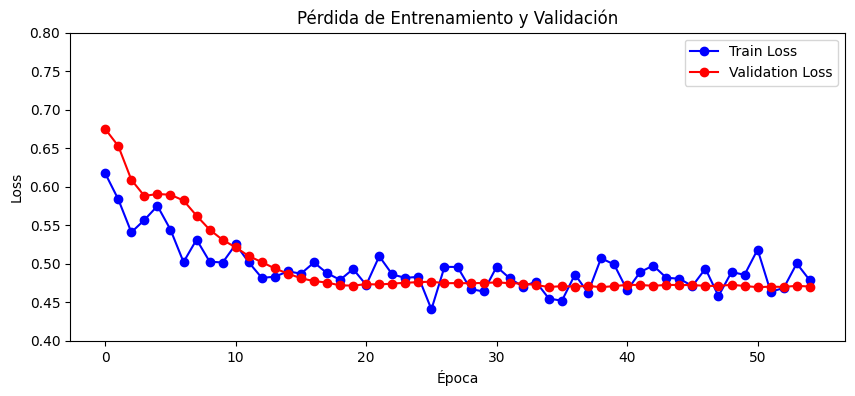

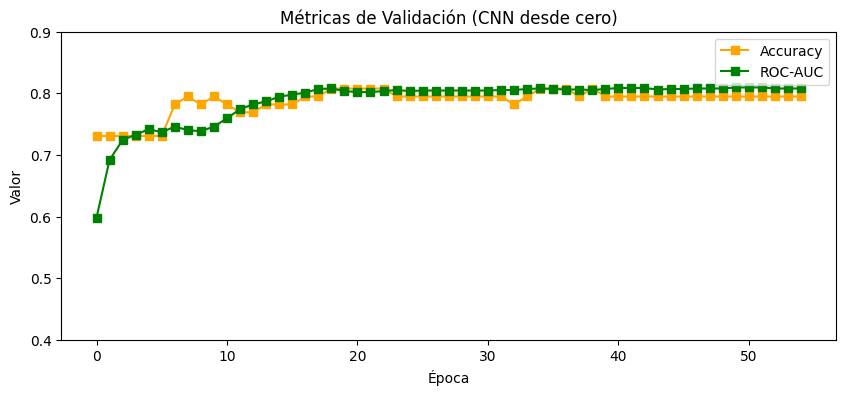

In [12]:
# Gráfico 1: Train Loss vs Val Loss
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train Loss", color="blue", marker="o")
plt.plot(history_scratch["val_loss"], label="Validation Loss", color="red", marker="o")
plt.title("Pérdida de Entrenamiento y Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.ylim(0.4, 0.8) # Se mantiene de 0.4 a 0.8
plt.legend()
plt.show()

# Gráfico 2: Accuracy vs ROC-AUC
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy", color="orange", marker="s")
plt.plot(history_scratch["val_auc"], label="ROC-AUC", color="green", marker="s")
plt.title("Métricas de Validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0.4, 0.9) # <--- Ajustado de 0.4 a 0.9
plt.legend()
plt.show()

Evaluación de SimpleCNN en el conjunto de prueba (Test)

In [13]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.8077
Test ROC-AUC:  0.7918

              precision    recall  f1-score   support

           0     0.6875    0.5238    0.5946        42
           1     0.8387    0.9123    0.8739       114

    accuracy                         0.8077       156
   macro avg     0.7631    0.7180    0.7343       156
weighted avg     0.7980    0.8077    0.7987       156



array([[ 22,  20],
       [ 10, 104]])

Visualización de la matriz de confusión (SimpleCNN)

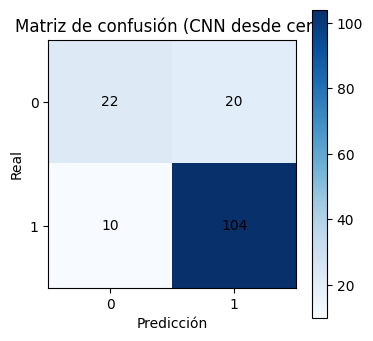

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues") # <--- Agregado el mapa de colores azul
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

Configuración de Data Augmentation para entrenamiento

In [15]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


Entrenamiento y validación de SimpleCNN con Data Augmentation

In [16]:
import numpy as np

model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
# Usamos el mismo learning rate de 2e-4 para que la curva sea continua y no se estanque
optimizer = torch.optim.Adam(model_aug.parameters(), lr=2e-4)

# Subimos a 55 épocas para darle tiempo de aprender con las imágenes rotadas
epochs = 55

# Agregamos val_loss al historial
history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    # Entrenamiento con el loader aumentado
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)

    # Cálculo manual de val_loss (igual que en el modelo base)
    model_aug.eval()
    val_losses = []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device).long().squeeze(1)
            loss = criterion(model_aug(x), y)
            val_losses.append(loss.item())
    val_loss = float(np.mean(val_losses))

    # Evaluación (desempaquetamos los 5 valores, ignorando los últimos 3)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6640 | val_loss=0.6848 | val_acc=0.7308 | val_auc=0.5748
Epoch 02 | train_loss=0.6540 | val_loss=0.6783 | val_acc=0.7308 | val_auc=0.5898
Epoch 03 | train_loss=0.6228 | val_loss=0.6754 | val_acc=0.7179 | val_auc=0.6040
Epoch 04 | train_loss=0.6075 | val_loss=0.6713 | val_acc=0.7179 | val_auc=0.6207
Epoch 05 | train_loss=0.6336 | val_loss=0.6642 | val_acc=0.7051 | val_auc=0.6483
Epoch 06 | train_loss=0.5861 | val_loss=0.6570 | val_acc=0.7051 | val_auc=0.6633
Epoch 07 | train_loss=0.5624 | val_loss=0.6390 | val_acc=0.7308 | val_auc=0.6800
Epoch 08 | train_loss=0.5605 | val_loss=0.6246 | val_acc=0.7051 | val_auc=0.6984
Epoch 09 | train_loss=0.5853 | val_loss=0.6096 | val_acc=0.6923 | val_auc=0.7101
Epoch 10 | train_loss=0.5365 | val_loss=0.5912 | val_acc=0.7051 | val_auc=0.7160
Epoch 11 | train_loss=0.5282 | val_loss=0.5787 | val_acc=0.7179 | val_auc=0.7310
Epoch 12 | train_loss=0.5660 | val_loss=0.5653 | val_acc=0.7179 | val_auc=0.7469
Epoch 13 | train_loss=0.5654

Comparación del desempeño en test (Sin vs. Con Data Augmentation)

In [17]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8077 | test_auc=0.7918
Con augmentation  | test_acc=0.8205 | test_auc=0.8177


Transformaciones y DataLoaders para Transfer Learning (ResNet-18)

In [18]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

Carga de ResNet-18 preentrenada y congelamiento del backbone (Feature Extraction)

In [19]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 75.4MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Entrenamiento de ResNet-18 - Etapa 1: Extracción de características (Feature Extraction)

In [20]:
import numpy as np

criterion = nn.CrossEntropyLoss()
# Entrenamos solo los parámetros de la capa final (fc)
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
# Agregamos val_loss al diccionario
history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    # Entrenamiento
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    # Cálculo manual de val_loss para poder graficarlo después
    resnet.eval()
    val_losses = []
    with torch.no_grad():
        for x, y in val_loader_tl:
            x = x.to(device)
            y = y.to(device).long().squeeze(1)
            loss = criterion(resnet(x), y)
            val_losses.append(loss.item())
    val_loss = float(np.mean(val_losses))

    # Evaluación (usando el loader del Transfer Learning)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage1 Epoch 01 | train_loss=0.6223 | val_loss=0.6261 | val_acc=0.7308 | val_auc=0.4002
Stage1 Epoch 02 | train_loss=0.5790 | val_loss=0.6239 | val_acc=0.7308 | val_auc=0.4670
Stage1 Epoch 03 | train_loss=0.5785 | val_loss=0.6228 | val_acc=0.7308 | val_auc=0.5572
Stage1 Epoch 04 | train_loss=0.5531 | val_loss=0.5689 | val_acc=0.7308 | val_auc=0.6065


Descongelamiento selectivo de capas para Fine-Tuning (Layer 4 + FC)

In [21]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

Entrenamiento de ResNet-18 - Etapa 2: Ajuste fino (Fine-Tuning)

In [26]:
import numpy as np

optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
# Agregamos la clave val_loss
history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    # Entrenamiento
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    # Cálculo manual de val_loss
    resnet.eval()
    val_losses = []
    with torch.no_grad():
        for x, y in val_loader_tl:
            x = x.to(device)
            y = y.to(device).long().squeeze(1)
            loss = criterion(resnet(x), y)
            val_losses.append(loss.item())
    val_loss = float(np.mean(val_losses))

    # Evaluación (desempaquetando los 5 valores)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage2 Epoch 01 | train_loss=0.2305 | val_loss=0.4687 | val_acc=0.8205 | val_auc=0.9173
Stage2 Epoch 02 | train_loss=0.1653 | val_loss=0.3251 | val_acc=0.8718 | val_auc=0.9198
Stage2 Epoch 03 | train_loss=0.1436 | val_loss=0.3300 | val_acc=0.8718 | val_auc=0.9365
Stage2 Epoch 04 | train_loss=0.1019 | val_loss=0.3622 | val_acc=0.8590 | val_auc=0.9340


Evaluación final y matriz de confusión (Transfer Learning - ResNet-18)

Transfer learning | test_acc=0.8269 | test_auc=0.8741

              precision    recall  f1-score   support

           0     0.8947    0.4048    0.5574        42
           1     0.8175    0.9825    0.8924       114

    accuracy                         0.8269       156
   macro avg     0.8561    0.6936    0.7249       156
weighted avg     0.8383    0.8269    0.8022       156



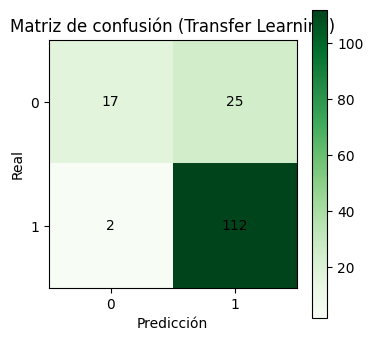

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluamos el modelo y calculamos las métricas
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}\n")
print(classification_report(y_true_tl, y_pred_tl, digits=4))

# 2. Creamos la variable cm_tl
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

# 3. Graficamos la matriz inmediatamente
plt.figure(figsize=(4, 4))
plt.imshow(cm_tl, cmap="Greens")
plt.title("Matriz de confusión (Transfer Learning)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_tl[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

Resumen consolidado de resultados en el conjunto de prueba

In [29]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8077 | auc=0.7918
CNN desde cero (con aug)  | acc=0.8205 | auc=0.8177
Transfer learning (ResNet) | acc=0.8269 | auc=0.8741


Definición de la función Grad-CAM para interpretabilidad del modelo

In [30]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


Visualización y superposición de mapas de activación Grad-CAM

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


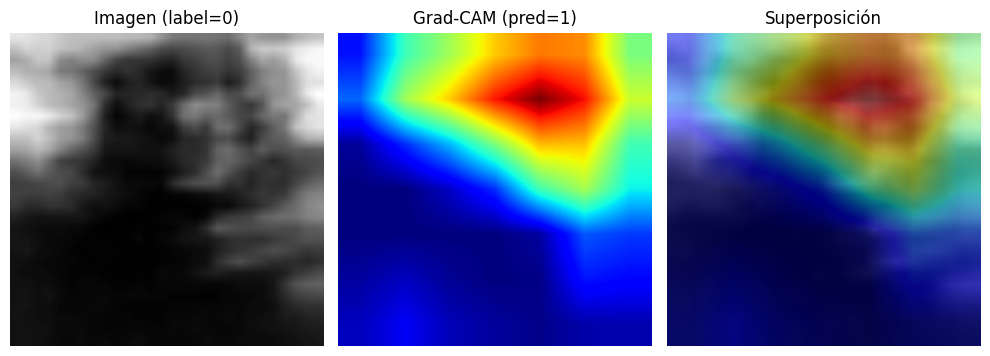

In [31]:
import cv2 # Usamos OpenCV para redimensionar el mapa

idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()

# Redimensionamos el mapa de 7x7 al tamaño de la imagen (224x224)
cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
# Usamos "jet" para darle colores térmicos (rojo=fuerte, azul=débil)
plt.imshow(cam_resized, cmap="jet")
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
# Superponemos usando el mapa redimensionado y colores térmicos
plt.imshow(cam_resized, cmap="jet", alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

Guardado y exportación de pesos de los modelos (Checkpoints)

In [32]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']